# Aula 11 — Regressão com scikit-learn

Nas Aulas 5, 6 e 7 vocês pegaram uma coleta de rede social e a **descreveram**: calcularam métricas, agruparam por hashtag, fizeram gráficos, escreveram um relatório. O trabalho era responder "o que os dados mostram".

Hoje começa outra coisa. Em vez de só descrever o que aconteceu, vamos pedir para o computador **aprender um padrão** a partir dos dados que temos e usar esse padrão para **estimar um número que ele não viu**. É a primeira aula de um bloco de três sobre aprendizado de máquina: hoje **regressão** (estimar um número), na próxima **classificação** (decidir uma categoria) e depois **clusterização** (agrupar sem resposta pronta).

A ferramenta nova é o `scikit-learn`, a biblioteca padrão de aprendizado de máquina em Python. Vimos um pouco dela no período passado. O código dela é curto e repetitivo, sempre o mesmo esqueleto: separar os dados, treinar o modelo, prever, medir o erro. O que exige atenção não é o código, é o resto: escolher o que entra no modelo, não se enganar com o número que ele cospe, e não confundir "o modelo achou uma relação" com "uma coisa causa a outra".

## 1. Preparando o ambiente

Esta aula usa `pandas` (que vocês já conhecem), `scikit-learn` e `matplotlib`. Instale as dependências registradas no `requirements.txt` desta pasta.

No Windows (Prompt de Comando ou Terminal integrado do VS Code), **dentro da pasta `aulas/11-regressao-scikit-learn/`:**

```cmd
uv venv .venv
uv pip install -r requirements.txt
```

Se o `uv` não funcionar:

```cmd
pip install -r requirements.txt
```

No Mac (Terminal ou Terminal integrado do VS Code), os mesmos comandos funcionam.

**OBS:** `scikit-learn` se instala com esse nome (com hífen), mas na hora de usar no código o nome é `sklearn` (sem hífen e sem o "scikit"). É assim mesmo, não é erro de digitação.

## 2. Aprendizado supervisionado, em uma frase

**Aprendizado supervisionado** é mostrar para o computador vários exemplos onde a resposta é conhecida, para que ele descubra sozinho a relação entre as informações de entrada e a resposta.

Duas peças, com nome fixo em qualquer material de aprendizado de máquina:

- **`X` (as *features*):** as colunas que descrevem cada exemplo. No nosso caso, cada linha é um post, e as features são coisas como quantos seguidores o autor tem, quantas hashtags o post usa, que horas ele foi publicado.
- **`y` (o *alvo*):** a coluna que queremos estimar. Hoje o alvo é a **taxa de engajamento** do post.

Quando o alvo é um **número contínuo** (0,03, 0,15, 0,08...), o problema se chama **regressão**. Quando o alvo é uma **categoria** ("viralizou" / "não viralizou"), aí é classificação, que é a próxima aula.

O modelo aprende com uma parte dos dados (o **treino**) e a gente testa se ele aprendeu de verdade numa parte que ele nunca viu (o **teste**). A Seção 5 volta nisso.

## 3. Carregando a coleta e construindo o alvo

`dados/exportacao.csv` é a mesma exportação de exemplo do TikTok que vocês usaram desde a Aula 5. Vamos carregar, remover duplicata e construir a **taxa de engajamento** por post, com a mesma fórmula da Aula 5:

`taxa_engajamento = (likes + comments + shares) / plays`

Essa é a coluna `y`, o alvo que o modelo vai tentar estimar.

In [3]:
import pandas as pd  # tabelas
import numpy as np  # operações numéricas (usaremos na Seção 8)
import matplotlib.pyplot as plt  # gráficos

df = pd.read_csv("dados/exportacao.csv", sep=";")  # mesma exportação das Aulas 5 a 7
df = df.drop_duplicates()  # remove linha idêntica a outra, se houver
df = df[df["plays"] > 0].copy()  # sem visualização não dá para calcular taxa (divisão por zero)

df["taxa_engajamento"] = (
    df["likes"] + df["comments"] + df["shares"]
) / df["plays"]  # o alvo: interações dividido por visualizações, por post

print(f"Posts na base: {len(df)}")
df["taxa_engajamento"].describe()

Posts na base: 640


count    640.000000
mean       0.070839
std        0.055475
min        0.000000
25%        0.028928
50%        0.046184
75%        0.106271
max        0.264249
Name: taxa_engajamento, dtype: float64

**O que observar:** a `taxa_engajamento` vai de 0 até uns 0,26, com metade dos posts abaixo de ~0,046. É esse número, entre 0 e 1, que o modelo vai aprender a estimar. Guarde a **média** (~0,07): ela vai virar o nosso "modelo bobo" de comparação na Seção 7.

## 4. Construindo as *features* — e o cuidado com vazamento

Agora as colunas de entrada, o `X`. A exportação não vem com features prontas para o modelo, então a gente **deriva** elas de colunas que já existem: contar hashtags, medir o tamanho da legenda, pegar a hora do post.

**ATENÇÃO — vazamento (*data leakage*):** as colunas `likes`, `comments`, `shares` e `plays` **não podem entrar no `X`**. Elas *são* o alvo (a taxa de engajamento foi calculada a partir delas). Usar elas para prever a taxa é como "prever" a nota de uma prova olhando o gabarito preenchido: o modelo acerta tudo no papel e não serve para nada no mundo real, porque no mundo real, quando você quer estimar o engajamento, o post ainda **não tem** curtida nenhuma. As features boas são as que existem **antes** de o post ser publicado: quem publicou, o que escreveu, quando postou.

In [4]:
import re  # para achar emojis no texto

# alvo separado
y = df["taxa_engajamento"]

# --- features derivadas, todas "de antes da publicação" ---
X = pd.DataFrame(index=df.index)  # tabela de features vazia, mesmo índice de df

# do autor
X["seguidores_autor"] = df["author_followers"]  # tamanho da audiência de quem postou
X["videos_autor"] = df["author_videos"]  # quantos vídeos o autor já publicou no total

# do texto (coluna body = legenda do post)
X["tam_legenda"] = df["body"].fillna("").str.len()  # nº de caracteres da legenda
padrao_emoji = re.compile("[\U0001F000-\U0001FAFF\u2600-\u27BF]")  # faixa Unicode de emojis
X["n_emojis"] = df["body"].fillna("").apply(lambda s: len(padrao_emoji.findall(s)))

# das hashtags (string separada por vírgula, pode ser vazia)
X["n_hashtags"] = df["hashtags"].fillna("").apply(
    lambda s: 0 if s == "" else len(s.split(","))
)

# do horário
momento = pd.to_datetime(df["timestamp"])  # converte o texto de data para datetime
X["hora"] = momento.dt.hour  # 0 a 23
X["dia_semana"] = momento.dt.dayofweek  # 0 = segunda ... 6 = domingo

X.head()

,seguidores_autor,videos_autor,tam_legenda,n_emojis,n_hashtags,hora,dia_semana
0,12200000,45600,1707,0,6,13,1
1,12200000,45600,754,0,5,13,1
2,12200000,45600,995,0,7,13,1
3,12200000,45600,767,0,6,13,1
4,12200000,45600,1892,0,5,12,1


**O que observar:** `X` tem 7 colunas, todas numéricas, nenhuma delas derivada de curtida/comentário/compartilhamento/visualização. Repare que `df["is_duet"]` e `df["is_ad"]` ficaram de fora de propósito: nesta coleta elas são quase sempre o mesmo valor ("no"), então não ajudam o modelo a distinguir um post do outro (a Seção 11 volta nisso).

## 5. Separando treino e teste

O modelo vai **decorar** os dados que ele vê no treino, isso é esperado. O que a gente quer saber é se ele **generaliza**: se o padrão que ele aprendeu também vale para posts que ele nunca viu.

Por isso a gente reserva uma fatia dos dados (aqui, 25%) que o modelo **não** usa para treinar. Depois medimos o erro só nessa fatia. Se o erro no teste for parecido com o do treino, o modelo aprendeu algo real. Se for muito pior, ele só decorou.

`random_state=42` fixa o sorteio de quais linhas vão para cada lado, para o resultado ser o mesmo toda vez que você rodar.

In [5]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.25,  # 25% dos posts ficam separados para teste
    random_state=42,  # sorteio reproduzível
)

print(f"Treino: {len(X_treino)} posts")
print(f"Teste:  {len(X_teste)} posts")

Treino: 480 posts
Teste:  160 posts


## 6. Treinando o primeiro modelo: regressão linear

`LinearRegression` procura a combinação de pesos (um por feature) que, multiplicados pelas features e somados, chegam o mais perto possível da taxa de engajamento real.

O esqueleto do scikit-learn é sempre este, para qualquer modelo:

1. `modelo = AlgumModelo()` — cria o modelo
2. `modelo.fit(X_treino, y_treino)` — treina (aprende os pesos)
3. `modelo.predict(X_teste)` — usa o modelo para estimar o alvo em dados novos

In [6]:
from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()  # 1. cria
modelo_linear.fit(X_treino, y_treino)  # 2. treina com o treino

previsoes = modelo_linear.predict(X_teste)  # 3. estima a taxa nos posts de teste

# comparando as 5 primeiras previsões com o valor real
comparacao = pd.DataFrame({
    "taxa_real": y_teste.values,
    "taxa_prevista": previsoes,
}).head()
comparacao

,taxa_real,taxa_prevista
0,0.073640,0.098500
1,0.062599,0.025326
2,0.026510,0.089929
3,0.127411,0.098243
4,0.054843,0.040357


**O que observar:** as previsões não batem exatamente com o real (nem deveriam), mas estão na mesma ordem de grandeza. A pergunta agora é: isso é **bom**? Para responder, precisamos de uma medida de erro e de algo com que comparar.

## 7. Medindo o erro: MAE, R² e o "modelo bobo"

Dois números resumem o desempenho de um modelo de regressão:

- **MAE (erro absoluto médio):** em média, quanto a previsão erra, na unidade do alvo. Um MAE de 0,04 quer dizer "em média o modelo erra a taxa de engajamento em 0,04 para cima ou para baixo".
- **R² (coeficiente de determinação):** o quanto da variação do alvo o modelo consegue explicar. `R² = 1` é perfeito; `R² = 0` significa "não é melhor do que chutar a média sempre"; `R² < 0` significa "é **pior** do que chutar a média".

Esse "chutar a média sempre" é o **modelo bobo** (*baseline*): o mínimo que qualquer modelo de verdade precisa superar. Se o seu modelo não bate o baseline, ele não aprendeu nada útil.

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_linear = mean_absolute_error(y_teste, previsoes)
r2_linear = r2_score(y_teste, previsoes)

# modelo bobo: prever a média do TREINO para todos os posts de teste
previsao_boba = np.full(len(y_teste), y_treino.mean())
mae_bobo = mean_absolute_error(y_teste, previsao_boba)
r2_bobo = r2_score(y_teste, previsao_boba)

print(f"Modelo bobo (só a média):  MAE = {mae_bobo:.4f}   R2 = {r2_bobo:.3f}")
print(f"Regressão linear:          MAE = {mae_linear:.4f}   R2 = {r2_linear:.3f}")

Modelo bobo (só a média):  MAE = 0.0449   R2 = -0.004
Regressão linear:          MAE = 0.0369   R2 = 0.278


**O que observar:** a regressão linear tem MAE menor e R² em torno de 0,28, contra ~0 do modelo bobo. Ou seja: ela aprendeu **algo**, mas explica menos de um terço da variação do engajamento. É um resultado modesto, e honesto: prever engajamento a partir de poucas features simples é difícil, e um R² de 0,28 numa coleta pequena não é vergonha nenhuma. O erro não é o modelo estar "ruim", é o fenômeno ser complicado.

## 8. Quando o alvo tem cauda longa: a transformação `log1p`

A nossa `taxa_engajamento` é um número bem comportado, entre 0 e 0,26. Mas e se quiséssemos prever o **número de visualizações** (`plays`) diretamente? Olhe a distribuição:

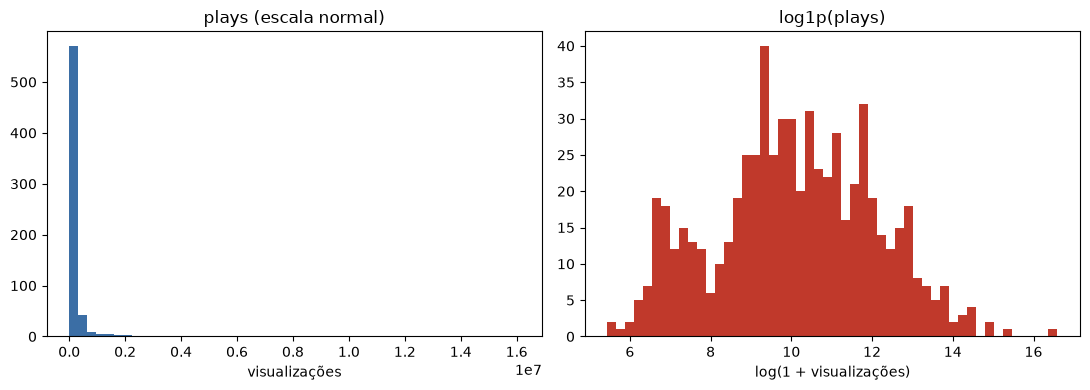

assimetria de plays:         17.3
assimetria de log1p(plays):  0.02


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(df["plays"], bins=50, color="#3b6ea5")
ax1.set_title("plays (escala normal)")
ax1.set_xlabel("visualizações")

ax2.hist(np.log1p(df["plays"]), bins=50, color="#c0392b")  # log1p(x) = log(1 + x)
ax2.set_title("log1p(plays)")
ax2.set_xlabel("log(1 + visualizações)")

fig.tight_layout()
plt.show()

print(f"assimetria de plays:         {df['plays'].skew():.1f}")
print(f"assimetria de log1p(plays):  {np.log1p(df['plays']).skew():.2f}")

**O que observar:** `plays` é dominado por pouquíssimos posts virais gigantes (milhões de views) e uma multidão de posts pequenos, tudo espremido perto do zero. Uma assimetria de 17 é altíssima. Depois de `np.log1p` (que é `log(1 + x)`, o `+1` evita `log(0)`), a distribuição fica quase simétrica.

Modelos lineares vão muito melhor com alvos simétricos. A regra prática: **se o histograma do seu alvo tem uma cauda longa para a direita, treine o modelo em `log1p(alvo)` e depois desfaça com `np.expm1` nas previsões.** Não vamos fazer isso hoje porque a nossa taxa de engajamento já é bem comportada, mas guarde a técnica para quando o alvo for contagem (views, curtidas, número de comentários).

## 9. Lendo os coeficientes: o que o modelo "achou"

Cada feature ganhou um peso no `modelo_linear`. Um peso positivo grande quer dizer "quando essa feature sobe, a taxa de engajamento prevista sobe"; negativo, o contrário. Como as features estão em escalas diferentes (seguidores na casa dos milhões, hora de 0 a 23), o valor bruto do coeficiente não dá para comparar direto, mas o **sinal** já conta uma história.

In [9]:
coeficientes = pd.DataFrame({
    "feature": X.columns,
    "coeficiente": modelo_linear.coef_,
}).sort_values("coeficiente")
coeficientes

,feature,coeficiente
5,hora,-9.245054e-04
2,tam_legenda,-7.711903e-05
3,n_emojis,-3.011850e-05
6,dia_semana,-2.024749e-05
0,seguidores_autor,-2.856487e-09
1,videos_autor,1.071728e-06
4,n_hashtags,2.036591e-05


**O que observar:** nesta coleta, `tam_legenda` e `seguidores_autor` ficaram com coeficiente **negativo** (legendas mais curtas e contas menores andam junto com taxa de engajamento maior, um padrão conhecido em redes sociais). Repare que a `hora` aparece com o maior coeficiente em valor absoluto: isso é só efeito de escala (hora vai de 0 a 23, seguidores vai até milhões, então o peso de seguidores *precisa* ser um número minúsculo para o resultado fechar). Por isso só o **sinal** é comparável entre features aqui, não o tamanho do coeficiente.

**ATENÇÃO — associação não é causa.** O modelo encontrou que legendas curtas *andam junto* com engajamento alto nesta coleta. Ele **não** provou que encurtar a legenda de um post *faz* o engajamento subir. Pode ser que vídeos de humor (que engajam muito) simplesmente usem legendas curtas, e o que importa é o humor, não o tamanho do texto. Um modelo de regressão descreve o que está correlacionado nos dados que ele viu; transformar isso em "faça X para conseguir Y" é um salto que os dados sozinhos não sustentam.

## 10. Um modelo não-linear: árvore de regressão

A regressão linear só enxerga relações em linha reta ("cada emoji a mais soma tanto na taxa"). Muita coisa no mundo real não é assim: talvez poucas hashtags não mudem nada, mas passar de 8 desabe o alcance. Uma **árvore de decisão** capta esse tipo de quebra, fazendo perguntas encadeadas ("seguidores > 1 milhão? legenda > 300 caracteres?") e prevendo um valor diferente em cada folha.

`max_depth=5` limita a árvore a 5 perguntas encadeadas, para ela não decorar o treino inteiro.

In [10]:
from sklearn.tree import DecisionTreeRegressor

modelo_arvore = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arvore.fit(X_treino, y_treino)
previsoes_arvore = modelo_arvore.predict(X_teste)

mae_arvore = mean_absolute_error(y_teste, previsoes_arvore)
r2_arvore = r2_score(y_teste, previsoes_arvore)

print(f"Modelo bobo:        MAE = {mae_bobo:.4f}   R2 = {r2_bobo:.3f}")
print(f"Regressão linear:   MAE = {mae_linear:.4f}   R2 = {r2_linear:.3f}")
print(f"Árvore (prof. 5):   MAE = {mae_arvore:.4f}   R2 = {r2_arvore:.3f}")

Modelo bobo:        MAE = 0.0449   R2 = -0.004
Regressão linear:   MAE = 0.0369   R2 = 0.278
Árvore (prof. 5):   MAE = 0.0228   R2 = 0.597


**O que observar:** a árvore vai melhor que a linear neste caso (R² mais alto, MAE menor), sinal de que a relação entre as features e o engajamento tem "quebras" que a linha reta não pegava. Isso **não** quer dizer que árvore é sempre melhor: em outras bases a linear ganha, e uma árvore sem `max_depth` decora o treino e vai mal no teste. A comparação com o baseline e a diferença entre erro de treino e de teste é que dizem qual modelo confiar, não a preferência por um algoritmo.

## 11. Quando der errado

- **R² lindo (0,95+) de primeira.** Quase sempre é vazamento: alguma coluna do `X` é o alvo disfarçado, ou foi calculada a partir dele. Reveja a lista de features e pergunte de cada uma: "esse dado já existe no momento em que eu quero fazer a previsão?". Se a resposta for não, tire a feature.
- **R² negativo.** O modelo é pior que chutar a média. Costuma ser feature sem relação nenhuma com o alvo, `X` e `y` desalinhados (linhas em ordem diferente), ou pouquíssimos dados de treino.
- **`ValueError: could not convert string to float`.** Alguma coluna do `X` ainda é texto. Colunas de categoria (`categoria`, `canal`) precisam virar número antes, com `pd.get_dummies(X, columns=[...])`. Colunas que *deveriam* ser número mas vieram como texto precisam de `pd.to_numeric(..., errors="coerce")`.
- **`ValueError: Input contains NaN`.** Sobrou valor ausente no `X`. Decida explicitamente: remover as linhas (`X.dropna()`, alinhando o `y` junto) ou preencher (`X.fillna(0)` ou `X.fillna(X.median())`), e registre a escolha.
- **Feature que não varia (só um valor).** Não quebra, mas é peso morto: o modelo não tem como usar `is_duet` se ela é "no" em todos os posts. Confira com `X.nunique()` e tire as colunas com valor único.
- **`ModuleNotFoundError: No module named 'sklearn'`.** O ambiente não foi criado ou as dependências não foram instaladas. Rode `uv venv .venv` e `uv pip install -r requirements.txt` de novo, dentro da pasta `aulas/11-regressao-scikit-learn/`. Lembre: instala como `scikit-learn`, importa como `sklearn`.

## 12. Prática: faça agora

Abra `exercicios/exercicio-11-regressao-scikit-learn.ipynb`. Você vai repetir o pipeline de hoje na **sua própria coleta** (a mesma das Aulas 5 a 7): construir a taxa de engajamento como alvo, derivar pelo menos três features próprias sem vazamento, treinar uma regressão linear e uma árvore, comparar as duas com o modelo bobo, e registrar num README quais features você usou e por que descartou as de vazamento.